In [23]:
import pandas as pd
import openpyxl 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = r"H:\1 - PYTHON\analise_dados\aula3 - Atividade 4\CD2022_Populacao_2010_Compatibilizada_20231222.xlsx"

In [3]:
formacao_bruto = pd.read_excel(path, header=2)

In [4]:
formacao_bruto

,Unnamed: 0,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População Município 2010\n(Sinopse),População 2010 (Alterações de Limites até 2022)1,População Censo 2022
0,NaN,RO,11.0,15.0,Alta Floresta D'Oeste,24392.0,24392.0,21494.0
1,NaN,RO,11.0,23.0,Ariquemes,90353.0,90353.0,96833.0
2,NaN,RO,11.0,31.0,Cabixi,6313.0,6313.0,5351.0
3,NaN,RO,11.0,49.0,Cacoal,78574.0,78574.0,86887.0
4,NaN,RO,11.0,56.0,Cerejeiras,17029.0,17029.0,15890.0
...,...,...,...,...,...,...,...,...
5569,NaN,DF,53.0,108.0,Brasília,2570160.0,2572159.0,2817381.0
5570,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5571,NaN,Nota: Para o cálculo das taxas de crescimento ...,NaN,NaN,NaN,NaN,NaN,NaN
5572,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
formacao_total = formacao_bruto.iloc[0:5570, 1:].copy()


formacao_total = formacao_total.reset_index(drop=True)

formacao_total.columns = [
    "uf",
    "cod_uf",
    "cod_munic",
    "nome_munic",
    "populacao_munic_2010",
    "pop_2010",
    "pop_2022",
]
formacao_total


,uf,cod_uf,cod_munic,nome_munic,populacao_munic_2010,pop_2010,pop_2022
0,RO,11.0,15.0,Alta Floresta D'Oeste,24392.0,24392.0,21494.0
1,RO,11.0,23.0,Ariquemes,90353.0,90353.0,96833.0
2,RO,11.0,31.0,Cabixi,6313.0,6313.0,5351.0
3,RO,11.0,49.0,Cacoal,78574.0,78574.0,86887.0
4,RO,11.0,56.0,Cerejeiras,17029.0,17029.0,15890.0
...,...,...,...,...,...,...,...
5565,GO,52.0,22005.0,Vianópolis,12548.0,12548.0,14956.0
5566,GO,52.0,22054.0,Vicentinópolis,7371.0,7373.0,8768.0
5567,GO,52.0,22203.0,Vila Boa,4735.0,4735.0,4215.0
5568,GO,52.0,22302.0,Vila Propício,5145.0,5145.0,5815.0


In [6]:

pop_estado = (
    formacao_total.groupby(["cod_uf", "uf"], as_index=False)
      .agg(
          populacao_2010=("pop_2010", "sum"),
          populacao_2022=("pop_2022", "sum"),
      )
)

pop_estado.to_csv(r"H:\1 - PYTHON\analise_dados\aula3 - Atividade 4\pop_estado.xlsx", sep =";")


In [21]:
pop_estado.sort_values(by="populacao_2022",ascending=False)

pop_estado["crescimento"] = pop_estado["populacao_2022"] - pop_estado["populacao_2010"]

estados_mais_crescem = pop_estado.sort_values(by="crescimento", ascending=False)

estados_mais_crescem = estados_mais_crescem.reset_index(drop=True)

estados_mais_crescem.to_csv(r"H:\1 - PYTHON\analise_dados\aula3 - Atividade 4\estados_mais_crescem.xlsx", sep =";")

estados_mais_crescem


,cod_uf,uf,populacao_2010,populacao_2022,crescimento
0,35.0,SP,41262199.0,44411238.0,3149039.0
1,42.0,SC,6248436.0,7610361.0,1361925.0
2,52.0,GO,6001789.0,7056495.0,1054706.0
3,41.0,PR,10444526.0,11444380.0,999854.0
4,31.0,MG,19597330.0,20539989.0,942659.0
5,51.0,MT,3035122.0,3658649.0,623527.0
6,15.0,PA,7581051.0,8120131.0,539080.0
7,13.0,AM,3483985.0,3941613.0,457628.0
8,23.0,CE,8451644.0,8794957.0,343313.0
9,32.0,ES,3514952.0,3833712.0,318760.0


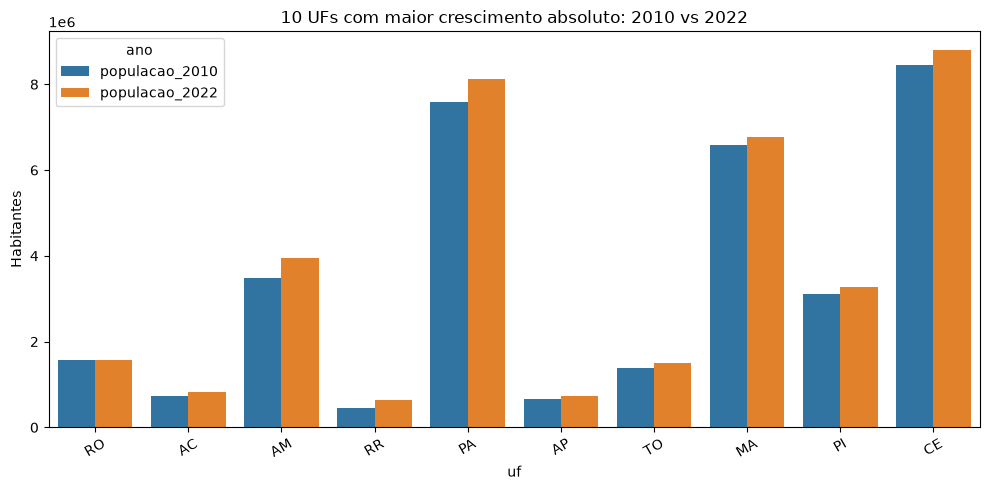

In [24]:
top = pop_estado.head(10).melt(
    id_vars="uf",
    value_vars=["populacao_2010", "populacao_2022"],
    var_name="ano",
    value_name="populacao",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top, x="uf", y="populacao", hue="ano", ax=ax)
ax.set_title("10 UFs com maior crescimento absoluto: 2010 vs 2022")
ax.set_ylabel("Habitantes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()